In [2]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SequentialSampler, RandomSampler

from einops import rearrange
from functools import partial

import matplotlib.pyplot as plt
import logging
import copy
import numpy as np

import math
import os, json
from typing import List,Tuple,Dict
import tqdm

import sys

sys.path.append(os.path.abspath('../ai4flow/acdm'))

from turbpred.data_transformations import Transforms
from turbpred.model_diffusion import DiffusionModel
from turbpred.params import DataParams
from turbpred.model import PredictionModel
from turbpred.logger import Logger
from turbpred.params import DataParams, TrainingParams, LossParams, ModelParamsEncoder, ModelParamsDecoder, ModelParamsLatent
from turbpred.turbulence_dataset import TurbulenceDataset
from turbpred.data_transformations import Transforms
from turbpred.loss import PredictionLoss
from turbpred.loss_history import LossHistory
from turbpred.trainer_diffusion import TrainerDiffusion, TesterDiffusion

/home/chunyang/miniconda3/envs/ACDM/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
from turbpred.foilslice_dataset import FoilsliceDataset, Transforms

# index for v2d dataset range: [54452, 99999]

trainSet = FoilsliceDataset(name="FoilSlice dataset",
                     dataDir="/home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed",
                     idx_range=[0, 1500],
                     sequenceLength=[1, 1], rey=1000)

Loading data from 	 /home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed
Loading completed. Files loaded: 	1500
Loading completed. Files loaded: 	1500

Dataset info detail:
	 Sequence length of each sample: 1
	 Sequence skiping samples of: 1


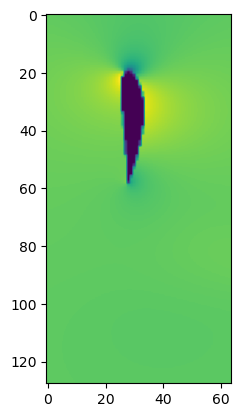

In [15]:
d = trainSet[0]["data"]
plt.imshow(d[0, 0, :, :])

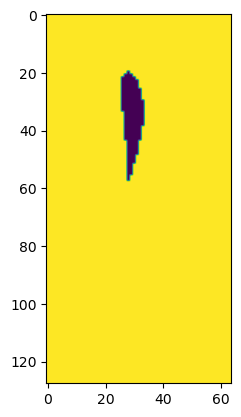

In [16]:
m = trainSet[0]["obsMask"]
# print("gigi", m.shape)
plt.imshow(m)
# print(m)

In [18]:
u_list = []
v_list = []
p_list = []

for i in tqdm.tqdm(range(len(trainSet))):
    u = trainSet[i]["data"][0, 0, :, :]
    v = trainSet[i]["data"][0, 1, :, :]
    p = trainSet[i]["data"][0, 2, :, :]
    u_list.append(u)
    v_list.append(v)
    p_list.append(p)

  0%|          | 1/1500 [00:00<05:31,  4.52it/s]

  0%|          | 2/1500 [00:00<05:28,  4.56it/s]

  0%|          | 3/1500 [00:00<05:05,  4.91it/s]

  0%|          | 4/1500 [00:00<05:13,  4.76it/s]

  0%|          | 5/1500 [00:01<05:03,  4.92it/s]

...

100%|█████████▉| 1496/1500 [05:29<00:01,  3.15it/s]

100%|█████████▉| 1497/1500 [05:29<00:00,  3.00it/s]

100%|█████████▉| 1498/1500 [05:29<00:00,  3.12it/s]

100%|█████████▉| 1499/1500 [05:30<00:00,  2.45it/s]

100%|██████████| 1500/1500 [05:30<00:00,  4.53it/s]

In [19]:
def find_mean_and_std(input):
    mean = np.mean(input)
    std = np.std(input)
    return mean, std

u_mean, u_std = find_mean_and_std(np.stack(u_list).flatten())
v_mean, v_std = find_mean_and_std(np.stack(v_list).flatten())
p_mean, p_std = find_mean_and_std(np.stack(p_list).flatten())

print(u_mean, u_std)
print(v_mean, v_std)
print(p_mean, p_std)

9248.837052804274 1595.1123198874222
-109.30064422252183 521.8374101854187
-1077520.188027851 5346411.390688729


# Inspect mean and std. after transformation

In [21]:
from turbpred.foilslice_dataset import Transforms

trainSet = FoilsliceDataset(name="FoilSlice dataset",
                     dataDir="/home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed",
                     idx_range=[0, 1500],
                     sequenceLength=[1, 1], rey=1000)

transTrain = Transforms()
trainSet.transform = transTrain

u_list = []
v_list = []
p_list = []

for i in tqdm.tqdm(range(len(trainSet))):
    u = trainSet[i]["data"][0, 0, :, :]
    v = trainSet[i]["data"][0, 1, :, :]
    p = trainSet[i]["data"][0, 2, :, :]
    u_list.append(u)
    v_list.append(v)
    p_list.append(p)
    
u_mean, u_std = find_mean_and_std(np.stack(u_list).flatten())
v_mean, v_std = find_mean_and_std(np.stack(v_list).flatten())
p_mean, p_std = find_mean_and_std(np.stack(p_list).flatten())

print(u_mean, u_std)
print(v_mean, v_std)
print(p_mean, p_std)

Loading data from 	 /home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed
Loading completed. Files loaded: 	1500
Loading completed. Files loaded: 	1500

Dataset info detail:
	 Sequence length of each sample: 1
	 Sequence skiping samples of: 1


100%|██████████| 1500/1500 [05:14<00:00,  4.76it/s]

9.132425e-08 1.0000004
1.899898e-08 1.0000012
1.993974e-07 0.9999997


# Inspect mean and std. after transformation for test data

In [22]:
testSet = FoilsliceDataset(name="FoilSlice dataset Test",
                     dataDir="/home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed",
                     idx_range=[1500, 1900],
                     sequenceLength=[1, 1], rey=1000)

transTest = Transforms()
testSet.transform = transTest

u_list = []
v_list = []
p_list = []

for i in tqdm.tqdm(range(len(testSet))):
    u = testSet[i]["data"][0, 0, :, :]
    v = testSet[i]["data"][0, 1, :, :]
    p = testSet[i]["data"][0, 2, :, :]
    u_list.append(u)
    v_list.append(v)
    p_list.append(p)
    
u_mean, u_std = find_mean_and_std(np.stack(u_list).flatten())
v_mean, v_std = find_mean_and_std(np.stack(v_list).flatten())
p_mean, p_std = find_mean_and_std(np.stack(p_list).flatten())

print(u_mean, u_std)
print(v_mean, v_std)
print(p_mean, p_std)

Loading data from 	 /home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed
Loading completed. Files loaded: 	400
Loading completed. Files loaded: 	400

Dataset info detail:
	 Sequence length of each sample: 1
	 Sequence skiping samples of: 1


  0%|          | 0/400 [00:00<?, ?it/s]

100%|██████████| 400/400 [01:21<00:00,  4.91it/s]

-0.07446248 1.0344133
-0.11577856 1.0382911
-0.76422524 1.0619844
